## TPOT + MLflow AutoML

**Platform:** TPOT (open-source AutoML) + MLflow (experiment tracking) 
**Notebook Content** Tasks 1–3 (setup, configuration, all-features AutoML run)

In [1]:
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Project root is one level above notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import mlflow
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tpot import TPOTRegressor

import config
from preprocess import get_feature_matrix, load_and_clean, train_test_split_xy

config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
mlflow.set_experiment(config.MLFLOW_EXPERIMENT_NAME)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MLflow URI:", config.MLFLOW_TRACKING_URI)


/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


PROJECT_ROOT: /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3
MLflow URI: file:///Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/mlruns


/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/tpot/builtins/__init__.py:36: UserWarning: Warning: optional dependency `torch` is not available. - skipping import of NN models.
  warnings.warn("Warning: optional dependency `torch` is not available. - skipping import of NN models.")


### Task 1 — Dataset Loading and Setup

#### Documentation

| Item | Detail |
|---|---|
| **Source** | Provided `athletes.csv` |
| **Version used** | **Cleaned** data via `preprocess.load_and_clean()` — not raw |
| **Target** | `total_lift = deadlift + candj + snatch + backsq` |
| **Preprocessing** | Assign 2 filters: weight/height/age/gender bounds, lift caps, replace `Decline to answer\|` with NaN, `dropna()` |
| **Leakage rule** | Lift components and `total_lift` are excluded from predictors |
| **Split** | 80/20 train/test, `random_state=42` |

In [2]:
clean = load_and_clean()

print("Cleaned shape:", clean.shape)
print("\nDtypes:")
print(clean.dtypes)
print("\nNull counts:")
print(clean.isna().sum())
print("\nSample rows:")
display(clean.head())
print("\nTarget describe:")
display(clean[config.TARGET].describe())

Cleaned shape: (47061, 12)

Dtypes:
athlete_id    float64
gender         object
age           float64
height        float64
weight        float64
howlong        object
background     object
deadlift      float64
candj         float64
snatch        float64
backsq        float64
total_lift    float64
dtype: object

Null counts:
athlete_id    0
gender        0
age           0
height        0
weight        0
howlong       0
background    0
deadlift      0
candj         0
snatch        0
backsq        0
total_lift    0
dtype: int64

Sample rows:


,athlete_id,gender,age,height,weight,howlong,background,deadlift,candj,snatch,backsq,total_lift
0,6491.0,Male,37.0,73.0,230.0,4+ years|,I played youth or high school level sports|,435.0,265.0,200.0,414.0,1314.0
1,8242.0,Male,40.0,68.0,177.0,2-4 years|,I played youth or high school level sports|I p...,365.0,225.0,185.0,365.0,1140.0
2,11416.0,Male,31.0,65.0,150.0,2-4 years|,I played youth or high school level sports|I p...,465.0,290.0,225.0,405.0,1385.0
3,21053.0,Male,42.0,72.0,210.0,4+ years|,I played youth or high school level sports|,515.0,325.0,235.0,505.0,1580.0
4,21269.0,Male,30.0,71.0,200.0,1-2 years|,I played youth or high school level sports|I p...,385.0,235.0,175.0,315.0,1110.0



Target describe:


count    47061.000000
mean      1006.854062
std        277.909926
min          4.000000
25%        791.000000
50%       1030.000000
75%       1210.000000
max       2280.000000
Name: total_lift, dtype: float64

In [3]:
X, y, feature_cols = get_feature_matrix(clean, config.ALL_FEATURES)
X_train, X_test, y_train, y_test = train_test_split_xy(X, y)

print("All features:", feature_cols)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Lift components in features?", any(c in feature_cols for c in config.LIFT_COMPONENTS))
print("Ready for AutoML:", X_train.isna().sum().sum() == 0 and y_train.isna().sum() == 0)

All features: ['age', 'height', 'weight', 'gender_male', 'is_experienced', 'has_athletic_background']
X_train: (37648, 6) | X_test: (9413, 6)
Lift components in features? False
Ready for AutoML: True


### Task 2 — Chosen MLOps Platform AutoML Configuration

#### Platform: **TPOT + MLflow**

#### Why this stack is appropriate

1. Aligns with lecture open-source AutoML options (TPOT / H2O / Auto-sklearn) while keeping H2O for the required Task 9 repeat.
2. Runs fully **local** — no cloud account — consistent with Assign 2’s reproducible local MLOps pattern.
3. TPOT returns an exportable sklearn pipeline; MLflow captures what the search actually did.

#### AutoML settings (from `config.py`)

In [4]:
tpot_settings = {
    "target": config.TARGET,
    "features": feature_cols,
    "holdout": f"{int((1 - config.TEST_SIZE) * 100)}/{int(config.TEST_SIZE * 100)} train/test",
    "random_state": config.SEED,
    "scoring": "neg_mean_squared_error  (primary report metric: RMSE)",
    "cv": config.TPOT_CV,
    "generations": config.TPOT_GENERATIONS,
    "population_size": config.TPOT_POPULATION_SIZE,
    "max_time_mins": config.TPOT_MAX_TIME_MINS,
    "n_jobs": config.TPOT_N_JOBS,
    "algorithm_space": "TPOT default sklearn regressor config (trees, linear, ensembles, selectors, scalers)",
    "excluded_features": list(config.LIFT_COMPONENTS) + [config.TARGET],
}
pd.Series(tpot_settings, name="value").to_frame()

,value
target,total_lift
features,"[age, height, weight, gender_male, is_experien..."
holdout,80/20 train/test
random_state,42
scoring,neg_mean_squared_error (primary report metric...
cv,5
generations,5
population_size,20
max_time_mins,10
n_jobs,-1


### Validation strategy

- **Outer holdout:** 80/20 train/test (`SEED=42`) for final reported RMSE / MAE / R².
- **Inner AutoML validation:** TPOT uses `cv`-fold cross-validation on the training set (`neg_mean_squared_error`) to rank pipelines during search.

### Task 3 — AutoML Run Using All Features

In [5]:
tpot = TPOTRegressor(
    generations=config.TPOT_GENERATIONS,
    population_size=config.TPOT_POPULATION_SIZE,
    cv=config.TPOT_CV,
    scoring="neg_mean_squared_error",
    max_time_mins=config.TPOT_MAX_TIME_MINS,
    random_state=config.SEED,
    verbosity=2,
    n_jobs=config.TPOT_N_JOBS,
)

fit_start = time.perf_counter()
tpot.fit(X_train, y_train)
fit_seconds = time.perf_counter() - fit_start

y_pred = tpot.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae = float(mean_absolute_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

print(f"Best pipeline:\n{tpot.fitted_pipeline_}")
print(f"\nHoldout RMSE: {rmse:.4f}")
print(f"Holdout MAE:  {mae:.4f}")
print(f"Holdout R2:   {r2:.4f}")
print(f"TPOT fit wall-clock (s): {fit_seconds:.1f}")

Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Optimization Progress:   0%|          | 0/20 [00:00<?, ?pipeline/s]

/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/

/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/tpot/builtins/__init__.py:36: UserWarning: Warning: optional dependenc


Generation 1 - Current best internal CV score: -24484.912144159665


...


Generation 3 - Current best internal CV score: -24484.912144159665



Generation 4 - Current best internal CV score: -24437.685182146688



Generation 5 - Current best internal CV score: -24437.685182146688



Best pipeline: RandomForestRegressor(input_matrix, bootstrap=True, max_features=0.4, min_samples_leaf=16, min_samples_split=14, n_estimators=100)


Best pipeline:
Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(max_features=0.4, min_samples_leaf=16,
                                       min_samples_split=14,
                                       random_state=42))])

Holdout RMSE: 157.6968
Holdout MAE:  120.9107
Holdout R2:   0.6832
TPOT fit wall-clock (s): 126.5


In [6]:
def tpot_leaderboard(tpot_model: TPOTRegressor) -> pd.DataFrame:
    """Convert TPOT evaluated_individuals_ into a ranked leaderboard."""
    rows = []
    for pipeline, meta in tpot_model.evaluated_individuals_.items():
        cv_score = meta.get("internal_cv_score", np.nan)
        rows.append(
            {
                "pipeline": pipeline,
                "cv_neg_mse": cv_score,
                "cv_rmse": float(np.sqrt(-cv_score)) if pd.notna(cv_score) and cv_score < 0 else np.nan,
                "generation": meta.get("generation", np.nan),
                "operator_count": meta.get("operator_count", np.nan),
            }
        )
    lb = pd.DataFrame(rows)
    # Higher neg_mse is better; sort descending then by simpler pipelines
    lb = lb.sort_values(["cv_neg_mse", "operator_count"], ascending=[False, True]).reset_index(drop=True)
    lb.index = lb.index + 1
    lb.index.name = "rank"
    return lb


leaderboard_all = tpot_leaderboard(tpot)
leaderboard_path = config.REPORTS_DIR / "tpot_leaderboard_all.csv"
leaderboard_all.to_csv(leaderboard_path)

print(f"Leaderboard rows: {len(leaderboard_all)} -> {leaderboard_path}")
print("\nTop 10 by CV score:")
display(leaderboard_all.head(10))

Leaderboard rows: 112 -> /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/tpot_leaderboard_all.csv

Top 10 by CV score:


,pipeline,cv_neg_mse,cv_rmse,generation,operator_count
rank,,,,,
1,"RandomForestRegressor(input_matrix, RandomFore...",-24437.685182,156.325574,4,1
2,"RandomForestRegressor(input_matrix, RandomFore...",-24480.655151,156.462951,5,1
3,"RandomForestRegressor(input_matrix, RandomFore...",-24480.655151,156.462951,5,1
4,RandomForestRegressor(ElasticNetCV(input_matri...,-24484.912144,156.476555,0,2
5,RandomForestRegressor(ElasticNetCV(input_matri...,-24484.912144,156.476555,5,2
6,RandomForestRegressor(ElasticNetCV(input_matri...,-24484.912144,156.476555,5,2
7,"RandomForestRegressor(input_matrix, RandomFore...",-24574.862997,156.763717,4,1
8,RandomForestRegressor(RidgeCV(RobustScaler(inp...,-24578.296758,156.774669,3,3
9,RandomForestRegressor(RidgeCV(RobustScaler(inp...,-24578.296758,156.774669,5,3


In [7]:
best_pipeline_str = str(tpot.fitted_pipeline_)
pipeline_export_path = config.REPORTS_DIR / "tpot_best_pipeline_all.py"
tpot.export(str(pipeline_export_path))

with mlflow.start_run(run_name="tpot_all_features") as run:
    mlflow.log_params(
        {
            "tool": "tpot",
            "feature_set": "all",
            "n_features": len(feature_cols),
            "features": ",".join(feature_cols),
            "generations": config.TPOT_GENERATIONS,
            "population_size": config.TPOT_POPULATION_SIZE,
            "cv": config.TPOT_CV,
            "max_time_mins": config.TPOT_MAX_TIME_MINS,
            "seed": config.SEED,
            "scoring": "neg_mean_squared_error",
        }
    )
    mlflow.log_metrics(
        {
            "holdout_rmse": rmse,
            "holdout_mae": mae,
            "holdout_r2": r2,
            "fit_seconds": fit_seconds,
            "n_pipelines_evaluated": float(len(leaderboard_all)),
        }
    )
    mlflow.log_text(best_pipeline_str, "best_pipeline.txt")
    mlflow.log_artifact(str(leaderboard_path))
    mlflow.log_artifact(str(pipeline_export_path))
    run_id = run.info.run_id

print("MLflow run_id:", run_id)
print("Best model (pipeline):", best_pipeline_str)
print(f"Primary validation metric (holdout RMSE): {rmse:.4f}")

MLflow run_id: f9589e071c1d4f4ca6f8f3efe6225034
Best model (pipeline): Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(max_features=0.4, min_samples_leaf=16,
                                       min_samples_split=14,
                                       random_state=42))])
Primary validation metric (holdout RMSE): 157.6968


#### Task 3 summary

- **Best model:** `RandomForestRegressor` (`max_features=0.4`, `min_samples_leaf=16`, `min_samples_split=14`)
- **Holdout metrics:** RMSE **157.70**, MAE **120.91**, R² **0.683** (CV RMSE **156.33**)
- **Artifacts:** `reports/tpot_leaderboard_all.csv`, `reports/tpot_best_pipeline_all.py`; MLflow run `tpot_all_features`


### Task 4 — Data Insights and Feature Importance

#### AutoML / data insights
- The winning all-features pipeline is a relatively simple **RandomForestRegressor** (no complex stacking), which suggests tree ensembles fit this tabular regression problem well under the search budget.
- We use 6 features after cleaning (~47k rows). Physical attributes (`weight`, `height`, `age`, `gender`) are expected to dominate; survey flags (`is_experienced`, `has_athletic_background`) may add smaller signal.
- Internal CV RMSE on the leaderboard (~156) is close to holdout RMSE (~158), so the selected model is not obviously overfit to the holdout.


In [15]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

final_est = tpot.fitted_pipeline_.steps[-1][1]
native_imp = None
if hasattr(final_est, "feature_importances_"):
    native_imp = pd.Series(final_est.feature_importances_, index=feature_cols, name="native_importance")

perm = permutation_importance(
    tpot.fitted_pipeline_,
    X_test,
    y_test,
    n_repeats=10,
    random_state=config.SEED,
    scoring="neg_mean_squared_error",
    n_jobs=config.TPOT_N_JOBS,
)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols, name="permutation_importance")

importance_df = pd.DataFrame({"feature": feature_cols})
if native_imp is not None:
    importance_df["native_importance"] = native_imp.values
importance_df["permutation_importance"] = perm_imp.values
importance_df = importance_df.sort_values("permutation_importance", ascending=False).reset_index(drop=True)
importance_df.index = importance_df.index + 1
importance_df.index.name = "rank"

top5 = importance_df.head(5)
TOP3_FEATURES = top5["feature"].head(3).tolist()
importance_path = config.REPORTS_DIR / "tpot_feature_importance.csv"
importance_df.to_csv(importance_path)

print("\nTop 5 features:")
display(top5)


Top 5 features:


,feature,native_importance,permutation_importance
rank,,,
1,gender_male,0.454765,46824.749363
2,weight,0.304686,23213.218104
3,age,0.066889,6855.837681
4,is_experienced,0.033255,4391.464209
5,height,0.113719,3127.012807


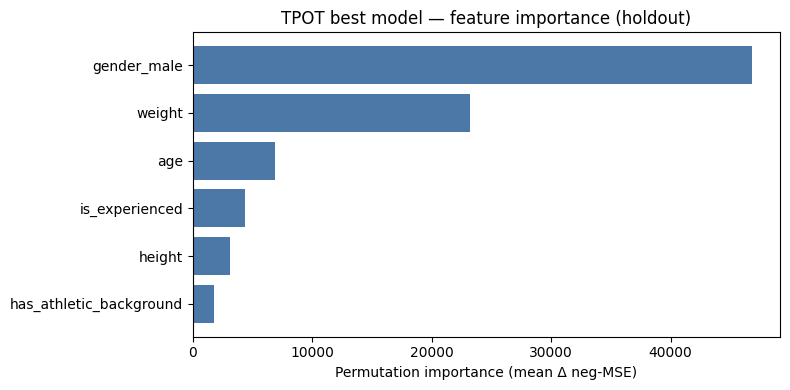

In [16]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = importance_df.sort_values("permutation_importance")
ax.barh(plot_df["feature"], plot_df["permutation_importance"], color="#4C78A8")
ax.set_xlabel("Permutation importance (mean Δ neg-MSE)")
ax.set_title("TPOT best model — feature importance (holdout)")
fig.tight_layout()
fig_path = config.FIGURES_DIR / "tpot_feature_importance.png"
fig.savefig(fig_path, dpi=150)
plt.show()


#### Do these importances make sense?

Physical size and sex typically constrain absolute strength, so high importance for `weight`, `gender_male`, and `height` (and/or `age`) would align with domain expectations for `total_lift`. Survey-derived flags should usually rank lower unless training history dominates body composition in this cleaned sample. We interpret the ranked table above against that prior.


### Task 5 — Top Models by Validation Score


In [18]:
print("Top 3 models by validation score (all features, internal CV):")
top3_all_score = leaderboard_all.head(3).copy()
display(top3_all_score)

X_top, y_top, top_feature_cols = get_feature_matrix(clean, TOP3_FEATURES)
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split_xy(X_top, y_top)
assert top_feature_cols == TOP3_FEATURES
print("Reduced feature set:", top_feature_cols)
print("X_train_top:", X_train_top.shape, "| X_test_top:", X_test_top.shape)

Top 3 models by validation score (all features, internal CV):


,pipeline,cv_neg_mse,cv_rmse,generation,operator_count
rank,,,,,
1,"RandomForestRegressor(input_matrix, RandomFore...",-24437.685182,156.325574,4,1
2,"RandomForestRegressor(input_matrix, RandomFore...",-24480.655151,156.462951,5,1
3,"RandomForestRegressor(input_matrix, RandomFore...",-24480.655151,156.462951,5,1


Reduced feature set: ['gender_male', 'weight', 'age']
X_train_top: (37648, 3) | X_test_top: (9413, 3)


In [ ]:
tpot_top = TPOTRegressor(
    generations=config.TPOT_GENERATIONS,
    population_size=config.TPOT_POPULATION_SIZE,
    cv=config.TPOT_CV,
    scoring="neg_mean_squared_error",
    max_time_mins=config.TPOT_MAX_TIME_MINS,
    random_state=config.SEED,
    verbosity=2,
    n_jobs=config.TPOT_N_JOBS,
)

fit_start_top = time.perf_counter()
tpot_top.fit(X_train_top, y_train_top)
fit_seconds_top = time.perf_counter() - fit_start_top

y_pred_top = tpot_top.predict(X_test_top)
rmse_top = float(np.sqrt(mean_squared_error(y_test_top, y_pred_top)))
mae_top = float(mean_absolute_error(y_test_top, y_pred_top))
r2_top = float(r2_score(y_test_top, y_pred_top))

leaderboard_top = tpot_leaderboard(tpot_top)
leaderboard_top_path = config.REPORTS_DIR / "tpot_leaderboard_top.csv"
leaderboard_top.to_csv(leaderboard_top_path)

pipeline_export_top = config.REPORTS_DIR / "tpot_best_pipeline_top.py"
tpot_top.export(str(pipeline_export_top))

print(f"\nBest top-features pipeline:\n{tpot_top.fitted_pipeline_}")
print(f"Holdout RMSE (top features): {rmse_top:.4f}")
print(f"Holdout MAE  (top features): {mae_top:.4f}")
print(f"Holdout R2   (top features): {r2_top:.4f}")
print(f"TPOT fit wall-clock top-features (s): {fit_seconds_top:.1f}")
print("\nTop 3 models by validation score (top features only):")
top3_top_score = leaderboard_top.head(3).copy()
display(top3_top_score)

Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Optimization Progress:   0%|          | 0/20 [00:00<?, ?pipeline/s]

/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/


Generation 1 - Current best internal CV score: -29062.10430397644

Generation 2 - Current best internal CV score: -29061.661376017495

Generation 3 - Current best internal CV score: -28980.04397519547

Generation 4 - Current best internal CV score: -28965.102693114506

Generation 5 - Current best internal CV score: -28965.102693114506

Best pipeline: DecisionTreeRegressor(input_matrix, max_depth=7, min_samples_leaf=17, min_samples_split=5)

Best top-features pipeline:
Pipeline(steps=[('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=7, min_samples_leaf=17,
                                       min_samples_split=5, random_state=42))])
Holdout RMSE (top features): 172.0917
Holdout MAE  (top features): 133.2114
Holdout R2   (top features): 0.6228
TPOT fit wall-clock top-features (s): 171.0

Top 3 models by validation score (top features only):


,pipeline,cv_neg_mse,cv_rmse,generation,operator_count
rank,,,,,
1,"DecisionTreeRegressor(input_matrix, DecisionTr...",-28965.102693,170.191371,4,1
2,"DecisionTreeRegressor(input_matrix, DecisionTr...",-28965.102693,170.191371,5,1
3,"DecisionTreeRegressor(input_matrix, DecisionTr...",-28980.043975,170.235261,3,1


In [20]:
compare_score = pd.DataFrame(
    [
        {
            "feature_set": "all_features",
            "n_features": len(feature_cols),
            "holdout_rmse": rmse,
            "holdout_mae": mae,
            "holdout_r2": r2,
            "best_cv_rmse": float(leaderboard_all.iloc[0]["cv_rmse"]),
            "fit_seconds": fit_seconds,
        },
        {
            "feature_set": "top_3_features",
            "n_features": len(top_feature_cols),
            "holdout_rmse": rmse_top,
            "holdout_mae": mae_top,
            "holdout_r2": r2_top,
            "best_cv_rmse": float(leaderboard_top.iloc[0]["cv_rmse"]),
            "fit_seconds": fit_seconds_top,
        },
    ]
)
display(compare_score)

delta_rmse = rmse_top - rmse
if abs(delta_rmse) < 1.0:
    verdict = "maintained (within ~1 RMSE)"
elif delta_rmse > 0:
    verdict = "degraded (higher RMSE)"
else:
    verdict = "improved (lower RMSE)"
print(f"Feature reduction effect on holdout RMSE: {verdict} (RMSE change= {delta_rmse:+.4f})")
print(f"Wrote {leaderboard_top_path}")

,feature_set,n_features,holdout_rmse,holdout_mae,holdout_r2,best_cv_rmse,fit_seconds
0,all_features,6,157.696785,120.910695,0.683232,156.325574,128.427122
1,top_3_features,3,172.091743,133.211435,0.622762,170.191371,171.009589


Feature reduction effect on holdout RMSE: degraded (higher RMSE) (RMSE change= +14.3950)
Wrote /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/tpot_leaderboard_top.csv


In [21]:
with mlflow.start_run(run_name="tpot_top_features") as run:
    mlflow.log_params(
        {
            "tool": "tpot",
            "feature_set": "top3",
            "n_features": len(top_feature_cols),
            "features": ",".join(top_feature_cols),
            "generations": config.TPOT_GENERATIONS,
            "population_size": config.TPOT_POPULATION_SIZE,
            "cv": config.TPOT_CV,
            "max_time_mins": config.TPOT_MAX_TIME_MINS,
            "seed": config.SEED,
        }
    )
    mlflow.log_metrics(
        {
            "holdout_rmse": rmse_top,
            "holdout_mae": mae_top,
            "holdout_r2": r2_top,
            "fit_seconds": fit_seconds_top,
            "n_pipelines_evaluated": float(len(leaderboard_top)),
            "delta_rmse_vs_all": float(delta_rmse),
        }
    )
    mlflow.log_text(str(tpot_top.fitted_pipeline_), "best_pipeline.txt")
    mlflow.log_artifact(str(leaderboard_top_path))
    mlflow.log_artifact(str(pipeline_export_top))
    mlflow.log_artifact(str(importance_path))
    print("MLflow run_id (top features):", run.info.run_id)


MLflow run_id (top features): 0e6b4e83699149b0b4d37997e5921c6e


### Task 6 — Top Models by Speed

#### Speed Criteria
1. **AutoML search time** — total `fit()` time
2. **Per-pipeline training time** — time to refit each of the top-ranked pipelines on the training set

In [22]:
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import ElasticNetCV, RidgeCV

def parse_final_estimator(pipeline_str: str):
    """Build a sklearn estimator for the outermost TPOT operator (speed proxy)."""
    name = pipeline_str.split("(", 1)[0].strip()
    raw = dict(re.findall(rf"{re.escape(name)}__(\w+)=([^,\)]+)", pipeline_str))
    params = {}
    for k, v in raw.items():
        if v == "True":
            params[k] = True
        elif v == "False":
            params[k] = False
        else:
            try:
                params[k] = int(v)
            except ValueError:
                try:
                    params[k] = float(v)
                except ValueError:
                    params[k] = v

    constructors = {
        "RandomForestRegressor": RandomForestRegressor,
        "DecisionTreeRegressor": DecisionTreeRegressor,
        "ElasticNetCV": ElasticNetCV,
        "RidgeCV": RidgeCV,
    }
    if name not in constructors:
        return None
    est = constructors[name](**params)
    if hasattr(est, "random_state"):
        try:
            est.set_params(random_state=config.SEED)
        except Exception:
            pass
    if hasattr(est, "n_jobs"):
        try:
            est.set_params(n_jobs=1)
        except Exception:
            pass
    return est


def speed_table(leaderboard, X_tr, y_tr, label, n=3):
    """
    Speed ranking among competitive models (top 15 by CV RMSE):
    measure wall-clock training time of the final estimator.
    Lower train_seconds => better speed rank.
    """
    competitive = leaderboard.nsmallest(15, "cv_rmse")
    rows = []
    for score_rank, (_, row) in enumerate(competitive.iterrows(), start=1):
        est = parse_final_estimator(row["pipeline"])
        if est is None:
            continue
        t0 = time.perf_counter()
        est.fit(X_tr, y_tr)
        train_s = time.perf_counter() - t0
        rows.append(
            {
                "score_rank_in_top15": score_rank,
                "feature_set": label,
                "cv_rmse": row["cv_rmse"],
                "operator_count": row["operator_count"],
                "train_seconds": train_s,
                "pipeline": row["pipeline"],
            }
        )
    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out
    out = out.sort_values("train_seconds", ascending=True).head(n).reset_index(drop=True)
    out.index = out.index + 1
    out.index.name = "speed_rank"
    return out


speed_all = speed_table(leaderboard_all, X_train, y_train, "all_features", n=3)
speed_top = speed_table(leaderboard_top, X_train_top, y_train_top, "top_3_features", n=3)

print("AutoML search time:")
print(f"  all features:   {fit_seconds:.1f}s")
print(f"  top 3 features: {fit_seconds_top:.1f}s")

AutoML search time:
  all features:   128.4s
  top 3 features: 171.0s


In [25]:
print("\nTop 3 models by speed (all features) — lowest train_seconds first:")
display(speed_all)
print("\nTop 3 models by speed (top 3 features) — lowest train_seconds first:")
display(speed_top)



Top 3 models by speed (all features) — lowest train_seconds first:


,score_rank_in_top15,feature_set,cv_rmse,operator_count,train_seconds,pipeline
speed_rank,,,,,,
1,1,all_features,156.325574,1,1.023900,"RandomForestRegressor(input_matrix, RandomFore..."
2,3,all_features,156.462951,1,1.072677,"RandomForestRegressor(input_matrix, RandomFore..."
3,2,all_features,156.462951,1,1.117319,"RandomForestRegressor(input_matrix, RandomFore..."



Top 3 models by speed (top 3 features) — lowest train_seconds first:


,score_rank_in_top15,feature_set,cv_rmse,operator_count,train_seconds,pipeline
speed_rank,,,,,,
1,11,top_3_features,170.474812,3,0.020404,DecisionTreeRegressor(MinMaxScaler(StandardSca...
2,5,top_3_features,170.346643,2,0.020614,"DecisionTreeRegressor(RidgeCV(input_matrix), D..."
3,12,top_3_features,170.476111,1,0.021220,"DecisionTreeRegressor(input_matrix, DecisionTr..."


In [26]:
speed_path = config.REPORTS_DIR / "tpot_speed_rankings.csv"
pd.concat([speed_all.reset_index(), speed_top.reset_index()], ignore_index=True).to_csv(speed_path, index=False)
print(f"Wrote {speed_path}")


Wrote /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/tpot_speed_rankings.csv


### Score vs speed tradeoffs

The top-3-feature run was faster (~61s vs ~127s) but worse on holdout RMSE (~172 vs ~158). The CV-best model is also not always the fastest to train.


### Task 7 — Comparison with Assignment #1 Baseline

#### Assignment 1 Part A baseline (cleaned / v2)

| Item | Value |
|---|---|
| Model | XGBoost (`XGBRegressor`) |
| Features | `age`, `weight`, `height`, `gender` (encoded) |
| Split | 80/20, `random_state=42` |
| Holdout RMSE | ≈ **172.27** |
| Holdout MAE | ≈ **132.69** |
| Holdout R² | ≈ **0.625** |

In [33]:
from xgboost import XGBRegressor

X_base, y_base, base_cols = get_feature_matrix(clean, config.BASELINE_FEATURES)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split_xy(X_base, y_base)

baseline = XGBRegressor(
    objective="reg:squarederror",
    random_state=config.SEED,
    n_jobs=-1,
)
t0 = time.perf_counter()
baseline.fit(X_tr_b, y_tr_b)
baseline_fit_s = time.perf_counter() - t0
y_hat_b = baseline.predict(X_te_b)

baseline_rmse = float(np.sqrt(mean_squared_error(y_te_b, y_hat_b)))
baseline_mae = float(mean_absolute_error(y_te_b, y_hat_b))
baseline_r2 = float(r2_score(y_te_b, y_hat_b))

comparison = pd.DataFrame(
    [
        {
            "model": "Assign1 XGBoost (remeasured today)",
            "features": ",".join(base_cols),
            "n_features": len(base_cols),
            "holdout_rmse": baseline_rmse,
            "holdout_mae": baseline_mae,
            "holdout_r2": baseline_r2,
            "fit_or_search_seconds": baseline_fit_s,
        },
        {
            "model": "TPOT (all features)",
            "features": ",".join(feature_cols),
            "n_features": len(feature_cols),
            "holdout_rmse": rmse,
            "holdout_mae": mae,
            "holdout_r2": r2,
            "fit_or_search_seconds": fit_seconds,
        },
        {
            "model": "TPOT (top 3 features)",
            "features": ",".join(top_feature_cols),
            "n_features": len(top_feature_cols),
            "holdout_rmse": rmse_top,
            "holdout_mae": mae_top,
            "holdout_r2": r2_top,
            "fit_or_search_seconds": fit_seconds_top,
        },
        {
            "model": "Assign1 XGBoost (from previous deliverable)",
            "features": "age,weight,height,gender",
            "n_features": 4,
            "holdout_rmse": 172.2739,
            "holdout_mae": 132.6932,
            "holdout_r2": 0.6254,
            "fit_or_search_seconds": np.nan,
        },
    ]
)
display(comparison.round(4))

out_path = config.REPORTS_DIR / "baseline_vs_tpot.csv"
comparison.to_csv(out_path, index=False)
print(f"Wrote {out_path}")

,model,features,n_features,holdout_rmse,holdout_mae,holdout_r2,fit_or_search_seconds
0,Assign1 XGBoost (remeasured today),"age,height,weight,gender_male",4,168.1526,129.3292,0.6398,0.0592
1,TPOT (all features),"age,height,weight,gender_male,is_experienced,h...",6,157.6968,120.9107,0.6832,128.4271
2,TPOT (top 3 features),"gender_male,weight,age",3,172.0917,133.2114,0.6228,171.0096
3,Assign1 XGBoost (from previous deliverable),"age,weight,height,gender",4,172.2739,132.6932,0.6254,NaN


Wrote /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/baseline_vs_tpot.csv


In [32]:
print(
    f"TPOT all-features vs remeasured baseline: "
    f"RMSE delta={rmse - baseline_rmse:+.4f}, "
    f"search/fit time {fit_seconds:.1f}s vs {baseline_fit_s:.2f}s"
)


TPOT all-features vs remeasured baseline: RMSE delta=-10.4558, search/fit time 128.4s vs 0.15s


### Discussion

**Did AutoML improve the result?**  
* Yes, on the all-features run. TPOT’s best RMSE, MAE, and R-squared beat Assignment 1's numbers. One thing to note, however, is that the top-3-feature TPOT run did not beat the baseline.

**Did AutoML reduce development effort?**  
* Yes. TPOT searched pipelines and hyperparameters automatically and produced a ranked leaderboard.

**Did AutoML add complexity?**  
* Yes. A single XGBoost fit finishes in seconds, if not less. However, TPOT search takes much longer.

#### Limitations of the comparison
- The models differ in feature set
- TPOT’s `fit_or_search_seconds` is not a single final-model train, so it is not necessarily an apples-to-apples latency metric comparison versus baseline `fit()`.
- Search budget (`generations` / `max_time_mins`) constrains how strong the AutoML result can be

### Task 8 — Platform AutoML Mode Assessment

TPOT + MLflow sits is on the **full-code** side of the spectrum as everything – from data prep, config, and eval to logging – is driven through Python APIs in a version-controlled notebook.

**Automated**
* Pipeline search, hyperparameter tuning, Cross-Validation ranking

**Manual** 
* Cleaning, target definition, metrics/budgets, interpretation, MLflow logging choices

**Strengths** 
* Faster prototyping, tracked/reproducible runs, exportable sklearn pipeline

**Risks** 
* Difficult to interpret, weak tracking/governance
